In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import random
import time

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import SubsetRandomSampler
from torch.utils.data import sampler
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'  # or ':16:8'

In [ ]:
cuda_device_num = 0
cuda_device = torch.device(f'cuda:{cuda_device_num}' if torch.cuda.is_available() else 'cpu')
print('Device:', cuda_device)

Device: cuda:0


In [ ]:
if torch.cuda.is_available():
  # Useful for reproducibility as it ensures that the same algorithms are used across runs.
  torch.backends.cudnn.benchmark = False
  # Ensures that the cuDNN operations are deterministic and, therefore, the same input will produce the same output every time
  torch.backends.cudnn.deterministic = True
# Ensures that operations in PyTorch will behave deterministically
torch.use_deterministic_algorithms(True)

In [ ]:
my_seed = 101
os.environ["PL_GLOBAL_SEED"] = str(my_seed)
random.seed(my_seed)
np.random.seed(my_seed)
torch.manual_seed(my_seed)
torch.cuda.manual_seed_all(my_seed)

In [ ]:
lr_rate = 0.0005
batch_size = 32
num_epochs = 20

In [ ]:
def get_dataloaders_mnist(batch_size, num_workers = 0,
                          validation_fraction = None,
                          train_transforms = None, test_transforms = None):

    if train_transforms is None:
        train_transforms = transforms.ToTensor()

    if test_transforms is None:
        test_transforms = transforms.ToTensor()

    train_dataset = datasets.MNIST(root = 'data',
                                   train = True,
                                   transform = train_transforms,
                                   download = True)

    valid_dataset = datasets.MNIST(root = 'data',
                                   train = True,
                                   transform = test_transforms)

    test_dataset = datasets.MNIST(root = 'data',
                                  train = False,
                                  transform = test_transforms)

    if validation_fraction is not None:
        num = int(validation_fraction * 60000)
        train_indices = torch.arange(0, 60000 - num)
        valid_indices = torch.arange(60000 - num, 60000)

        train_sampler = SubsetRandomSampler(train_indices)
        valid_sampler = SubsetRandomSampler(valid_indices)

        valid_loader = DataLoader(dataset = valid_dataset,
                                  batch_size = batch_size,
                                  num_workers = num_workers,
                                  sampler = valid_sampler)

        train_loader = DataLoader(dataset = train_dataset,
                                  batch_size = batch_size,
                                  num_workers = num_workers,
                                  drop_last = True,
                                  sampler = train_sampler)
    else:
        train_loader = DataLoader(dataset = train_dataset,
                                  batch_size = batch_size,
                                  num_workers = num_workers,
                                  shuffle = True)

    test_loader = DataLoader(dataset = test_dataset,
                             batch_size = batch_size,
                             num_workers = num_workers,
                             shuffle = False)

    if validation_fraction is None:
        return train_loader, test_loader
    else:
        return train_loader, valid_loader, test_loader

In [ ]:
train_loader, valid_loader, test_loader = get_dataloaders_mnist(
    batch_size = batch_size,
    num_workers = 2,
    validation_fraction = 0.)

In [ ]:
# Dataset Sanity check 1:
print('Training Set:\n')
for images, labels in train_loader:
    print('Image batch dimensions:', images.size())
    print('Image label dimensions:', labels.size())
    print(labels[:10])
    break

# Dataset Sanity check 2:
print('\nValidation Set:')
for images, labels in valid_loader:
    print('Image batch dimensions:', images.size())
    print('Image label dimensions:', labels.size())
    print(labels[:10])
    break

# Dataset Sanity check 3:
print('\nTesting Set:')
for images, labels in test_loader:
    print('Image batch dimensions:', images.size())
    print('Image label dimensions:', labels.size())
    print(labels[:10])
    break

Training Set:

Image batch dimensions: torch.Size([32, 1, 28, 28])
Image label dimensions: torch.Size([32])
tensor([0, 5, 7, 8, 6, 7, 9, 7, 1, 3])

Validation Set:

Testing Set:
Image batch dimensions: torch.Size([32, 1, 28, 28])
Image label dimensions: torch.Size([32])
tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


In [ ]:
# Helper Class 1: Reshape is used to reshape the embeddings to the correct image size
class Reshape(nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.shape = args

    def forward(self, x):
        return x.view(self.shape)

In [ ]:
# Helper Class 2: Trim is used to remove the excess pixels at the output of the decoder block (28x28 as MNIST size)
class Trim(nn.Module):
    def __init__(self, *args):
        super().__init__()

    def forward(self, x):
        return x[:, :, :28, :28]

In [ ]:
class Conv_AutoEncoder(nn.Module):
    def __init__(self, embedding_size=2):  # Modified embedding_size
        super().__init__()

        self.encoder = nn.Sequential(
                nn.Conv2d(1, 32, stride = (1, 1), kernel_size = (3, 3), padding = 1),
                nn.LeakyReLU(0.01),
                nn.Conv2d(32, 64, stride = (2, 2), kernel_size = (3, 3), padding = 1),
                nn.LeakyReLU(0.01),
                nn.Conv2d(64, 64, stride = (2, 2), kernel_size = (3, 3), padding = 1),
                nn.LeakyReLU(0.01),
                nn.Conv2d(64, 64, stride = (1, 1), kernel_size = (3, 3), padding = 1),
                nn.Flatten(),
                nn.Linear(3136, embedding_size)  # Changed embedding_size
        )
        self.decoder = nn.Sequential(
                torch.nn.Linear(embedding_size, 3136),  # Changed embedding_size
                Reshape(-1, 64, 7, 7),
                nn.ConvTranspose2d(64, 64, stride = (1, 1), kernel_size = (3, 3), padding = 1),
                nn.LeakyReLU(0.01),
                nn.ConvTranspose2d(64, 64, stride = (2, 2), kernel_size = (3, 3), padding = 1),
                nn.LeakyReLU(0.01),
                nn.ConvTranspose2d(64, 32, stride = (2, 2), kernel_size = (3, 3), padding = 0),
                nn.LeakyReLU(0.01),
                nn.ConvTranspose2d(32, 1, stride = (1, 1), kernel_size = (3, 3), padding = 0),
                Trim(),  # 1x29x29 -> 1x28x28
                nn.Sigmoid()
                )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
model = Conv_AutoEncoder()
model.to(cuda_device)

optimizer = torch.optim.Adam(model.parameters(), lr = lr_rate)

In [ ]:
def compute_epoch_loss_autoencoder(model, data_loader, loss_fn, device):
    model.eval()
    curr_loss, num_examples = 0., 0
    with torch.no_grad():
        for features, _ in data_loader:
            features = features.to(device)
            logits = model(features)
            loss = loss_fn(logits, features, reduction = 'sum')
            num_examples += features.size(0)
            curr_loss += loss

        curr_loss = curr_loss / num_examples
        return curr_loss

In [ ]:
def train_autoencoder_v1(num_epochs, model, optimizer, device,
                         train_loader, loss_fn = None,
                         logging_interval = 100,
                         skip_epoch_stats = False,
                         save_model = None):

    log_dict = {'train_loss_per_batch': [],
                'train_loss_per_epoch': []}

    if loss_fn is None:
        loss_fn = F.mse_loss

    start_time = time.time()
    for epoch in range(num_epochs):

        model.train()
        for batch_idx, (features, _) in enumerate(train_loader):

            features = features.to(device)

            # Forward and backpropagation ste[s]
            logits = model(features)
            loss = loss_fn(logits, features)
            optimizer.zero_grad()

            loss.backward()

            # Model weights' update
            optimizer.step()

            # Performance logging
            log_dict['train_loss_per_batch'].append(loss.item())

            if not batch_idx % logging_interval:
                print('Epoch: %03d/%03d | Batch %04d/%04d | Loss: %.4f'
                      % (epoch+1, num_epochs, batch_idx,
                          len(train_loader), loss))

        if not skip_epoch_stats:
            model.eval()

            with torch.set_grad_enabled(False):  # Will help save memory during inference

                train_loss = compute_epoch_loss_autoencoder(
                    model, train_loader, loss_fn, device)
                print('***Epoch: %03d/%03d | Loss: %.3f' % (
                      epoch+1, num_epochs, train_loss))
                log_dict['train_loss_per_epoch'].append(train_loss.item())

        print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))

    print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))
    if save_model is not None:
        torch.save(model.state_dict(), save_model)

    return log_dict

In [ ]:
log_dict = train_autoencoder_v1(num_epochs = num_epochs, model = model,
                                optimizer = optimizer, device = cuda_device,
                                train_loader = train_loader,
                                skip_epoch_stats = True,
                                logging_interval = 250)

Epoch: 001/020 | Batch 0000/1875 | Loss: 0.2602
Epoch: 001/020 | Batch 0250/1875 | Loss: 0.0629
Epoch: 001/020 | Batch 0500/1875 | Loss: 0.0545
Epoch: 001/020 | Batch 0750/1875 | Loss: 0.0531
Epoch: 001/020 | Batch 1000/1875 | Loss: 0.0444
Epoch: 001/020 | Batch 1250/1875 | Loss: 0.0426
Epoch: 001/020 | Batch 1500/1875 | Loss: 0.0457
Epoch: 001/020 | Batch 1750/1875 | Loss: 0.0480
Time elapsed: 0.41 min
Epoch: 002/020 | Batch 0000/1875 | Loss: 0.0428
Epoch: 002/020 | Batch 0250/1875 | Loss: 0.0401
Epoch: 002/020 | Batch 0500/1875 | Loss: 0.0445
Epoch: 002/020 | Batch 0750/1875 | Loss: 0.0437
Epoch: 002/020 | Batch 1000/1875 | Loss: 0.0399
Epoch: 002/020 | Batch 1250/1875 | Loss: 0.0442
Epoch: 002/020 | Batch 1500/1875 | Loss: 0.0453
Epoch: 002/020 | Batch 1750/1875 | Loss: 0.0502
Time elapsed: 0.75 min
Epoch: 003/020 | Batch 0000/1875 | Loss: 0.0380
Epoch: 003/020 | Batch 0250/1875 | Loss: 0.0417
Epoch: 003/020 | Batch 0500/1875 | Loss: 0.0435
Epoch: 003/020 | Batch 0750/1875 | Loss: 0

In [ ]:
torch.save(model.state_dict(), '/content/conv_ae_model.pth')

In [ ]:
torch.save(model, '/content/conv_ae_model_complete.pth')

In [ ]:
def plot_training_loss(minibatch_losses, num_epochs, averaging_iterations = 100, custom_label = ''):

    iter_per_epoch = len(minibatch_losses) // num_epochs

    plt.figure()
    ax1 = plt.subplot(1, 1, 1)
    ax1.plot(range(len(minibatch_losses)),
             (minibatch_losses), label = f'Minibatch Loss{custom_label}')
    ax1.set_xlabel('Iterations')
    ax1.set_ylabel('Loss')

    if len(minibatch_losses) < 1000:
        num_losses = len(minibatch_losses) // 2
    else:
        num_losses = 1000

    ax1.set_ylim([
        0, np.max(minibatch_losses[num_losses:])*1.5
        ])

    ax1.plot(np.convolve(minibatch_losses,
                         np.ones(averaging_iterations,)/averaging_iterations,
                         mode = 'valid'),
             label = f'Running Average{custom_label}')
    ax1.legend()

    ###################
    # Set scond x-axis
    ax2 = ax1.twiny()
    newlabel = list(range(num_epochs+1))

    newpos = [e*iter_per_epoch for e in newlabel]

    ax2.set_xticks(newpos[::10])
    ax2.set_xticklabels(newlabel[::10])

    ax2.xaxis.set_ticks_position('bottom')
    ax2.xaxis.set_label_position('bottom')
    ax2.spines['bottom'].set_position(('outward', 45))
    ax2.set_xlabel('Epochs')
    ax2.set_xlim(ax1.get_xlim())
    ###################

    plt.tight_layout()

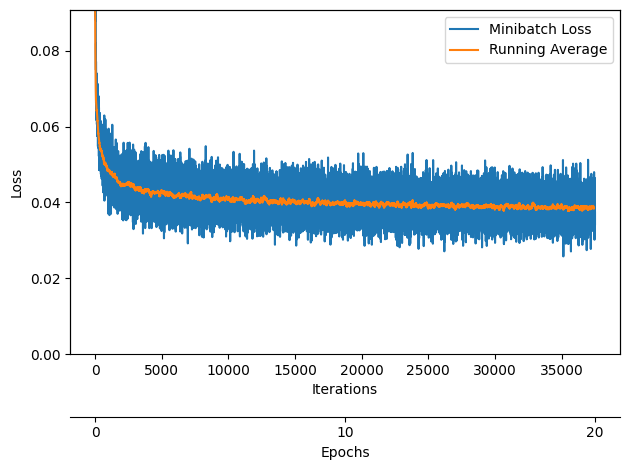

In [ ]:
plot_training_loss(log_dict['train_loss_per_batch'], num_epochs)
plt.show()

In [ ]:
def plot_generated_images(data_loader, model, device,
                          unnormalizer = None,
                          figsize = (20, 2.5), n_images = 15, modeltype = 'autoencoder'):

    fig, axes = plt.subplots(nrows = 2, ncols = n_images,
                             sharex = True, sharey = True, figsize = figsize)

    for batch_idx, (features, _) in enumerate(data_loader):

        features = features.to(device)

        color_channels = features.shape[1]
        image_height = features.shape[2]
        image_width = features.shape[3]

        with torch.no_grad():
            if modeltype == 'autoencoder':
                decoded_images = model(features)[:n_images]
            elif modeltype == 'VAE':
                encoded, z_mean, z_log_var, decoded_images = model(features)[:n_images]
            else:
                raise ValueError('`modeltype` not supported')

        orig_images = features[:n_images]
        break

    for i in range(n_images):
        for ax, img in zip(axes, [orig_images, decoded_images]):
            curr_img = img[i].detach().to(torch.device('cpu'))
            if unnormalizer is not None:
                curr_img = unnormalizer(curr_img)

            if color_channels > 1:
                curr_img = np.transpose(curr_img, (1, 2, 0))
                ax[i].imshow(curr_img)
            else:
                ax[i].imshow(curr_img.view((image_height, image_width)), cmap = 'binary')

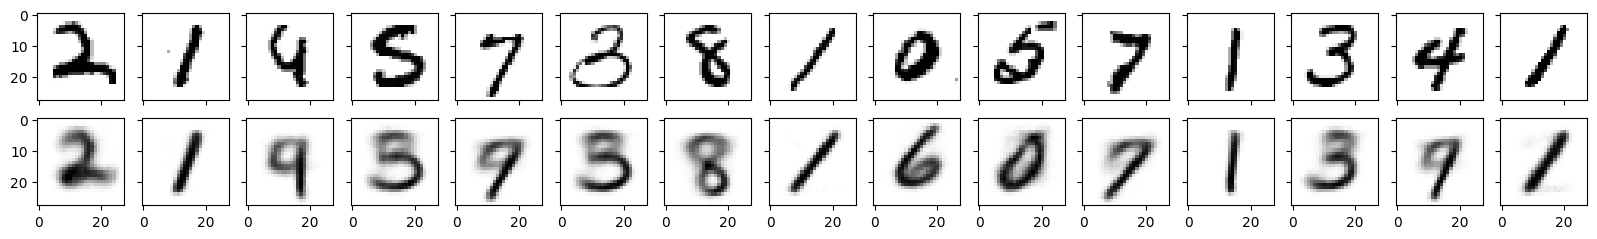

In [ ]:
plot_generated_images(data_loader = train_loader, model = model, device = cuda_device)

In [ ]:
def plot_latent_space_with_labels(num_classes, data_loader, model, device):
    d = {i:[] for i in range(num_classes)}

    model.eval()
    with torch.no_grad():
        for i, (features, targets) in enumerate(data_loader):

            features = features.to(device)
            targets = targets.to(device)

            embedding = model.encoder(features)

            for i in range(num_classes):
                if i in targets:
                    mask = targets == i
                    d[i].append(embedding[mask].to('cpu').numpy())

    colors = list(mcolors.TABLEAU_COLORS.items())
    for i in range(num_classes):
        d[i] = np.concatenate(d[i])
        plt.scatter(
            d[i][:, 0], d[i][:, 1],
            color = colors[i][1],
            label = f'{i}',
            alpha = 0.5)

    plt.legend()

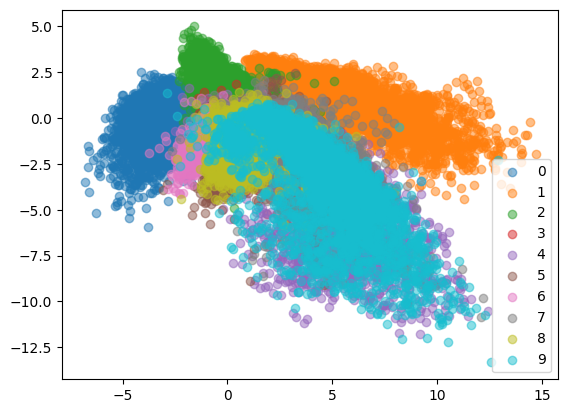

In [ ]:
num_classes = 10
plot_latent_space_with_labels(
    num_classes = num_classes,
    data_loader = train_loader,
    model = model,
    device = cuda_device)

plt.legend()
plt.show()

In [ ]:
#PCA to display the 2D projection
def plot_latent_space_with_pca(embeddings, labels, num_classes=10, title="PCA Projection"):
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    colors = list(mcolors.TABLEAU_COLORS.values())

    for i in range(num_classes):
        idx = (labels == i)
        plt.scatter(
            embeddings_2d[idx, 0],
            embeddings_2d[idx, 1],
            color=colors[i % len(colors)],
            label=f'{i}',
            alpha=0.6
        )

    plt.title(title)
    plt.xlabel(f"PC1 (Explained Var: {pca.explained_variance_ratio_[0]:.2f})")
    plt.ylabel(f"PC2 (Explained Var: {pca.explained_variance_ratio_[1]:.2f})")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# t-SNE projection
def plot_latent_space_with_tsne(embeddings, labels, num_classes=10, title="t-SNE Projection"):
    tsne = TSNE(n_components=2, perplexity=30, random_state=my_seed)
    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    colors = list(mcolors.TABLEAU_COLORS.values())

    for i in range(num_classes):
        idx = (labels == i)
        plt.scatter(
            embeddings_2d[idx, 0],
            embeddings_2d[idx, 1],
            color=colors[i % len(colors)],
            label=f'{i}',
            alpha=0.6
        )

    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

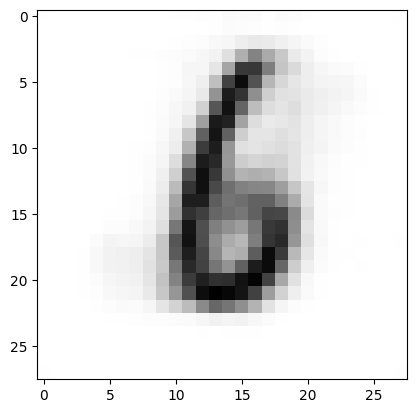

In [ ]:
with torch.no_grad():
    new_image = model.decoder(torch.randn(1,2).to(cuda_device))
    new_image.squeeze_(0)
    new_image.squeeze_(0)
plt.imshow(new_image.to('cpu').numpy(), cmap = 'binary')
plt.show()

In [ ]:
model = Conv_AutoEncoder()  # Initialize the model
# Option 1: Loading model params
model.load_state_dict(torch.load('/content/conv_ae_model.pth'))
model.to(cuda_device) # This line is added to move the model to the GPU
model.eval()  # Set to evaluation mode

# Option 2: Loading full model
# model = torch.load('/content/conv_ae_model_complete.pth')
# model.eval()  # Set to evaluation mode

Conv_AutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Flatten(start_dim=1, end_dim=-1)
    (8): Linear(in_features=3136, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=3136, bias=True)
    (1): Reshape()
    (2): ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.01)
    (4): ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.01)
    (6): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2))
    (7): L

In [ ]:
all_embeddings = torch.zeros((10_000, 2))

num_images = 0
for images, labels in train_loader:

    if num_images >= 10_000:
        break

    begin = num_images
    end = begin + images.size(0)
    end = min(end, 10_000)


    images, labels = images.to(cuda_device), labels.to(cuda_device)

    with torch.no_grad():
        embeddings = model.encoder(images).to('cpu')

    # Adjust the slice size to match the available space:
    all_embeddings[begin:end] = embeddings[:end-begin]


    num_images = end

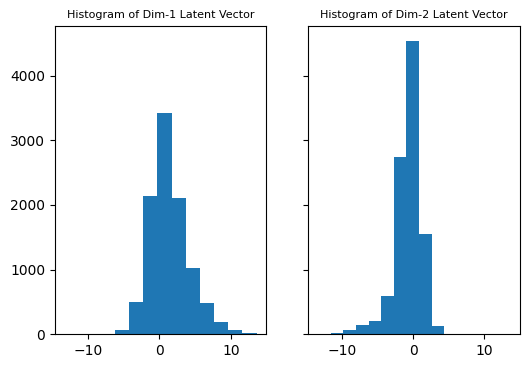

In [ ]:
fig, axes = plt.subplots(nrows = 1, ncols = 2,
                         sharex = True, sharey = True,
                         figsize = (6, 4))

axes[0].hist(all_embeddings[:, 0].numpy())
axes[0].set_title('Histogram of Dim-1 Latent Vector', fontsize = 8)
axes[1].hist(all_embeddings[:, 1].numpy())
axes[1].set_title('Histogram of Dim-2 Latent Vector', fontsize = 8)
plt.show()

#PCA & t-SNE visualization



Collected 10000 embeddings with dimension 2
PCA visualization


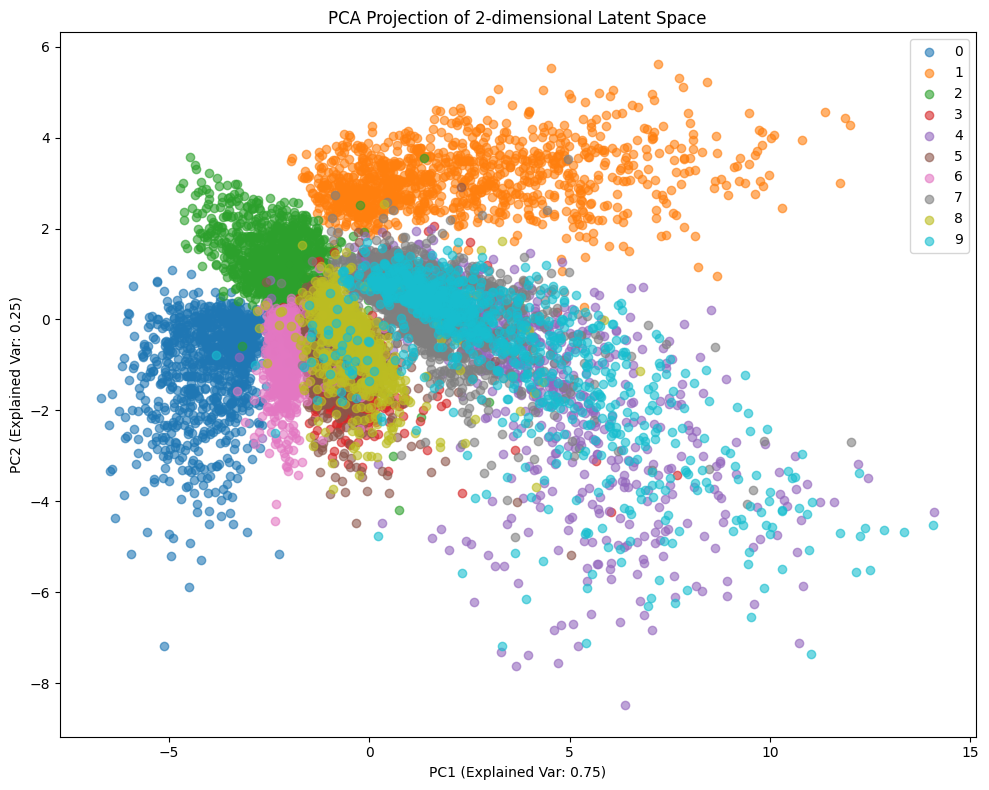

t-SNE visualization


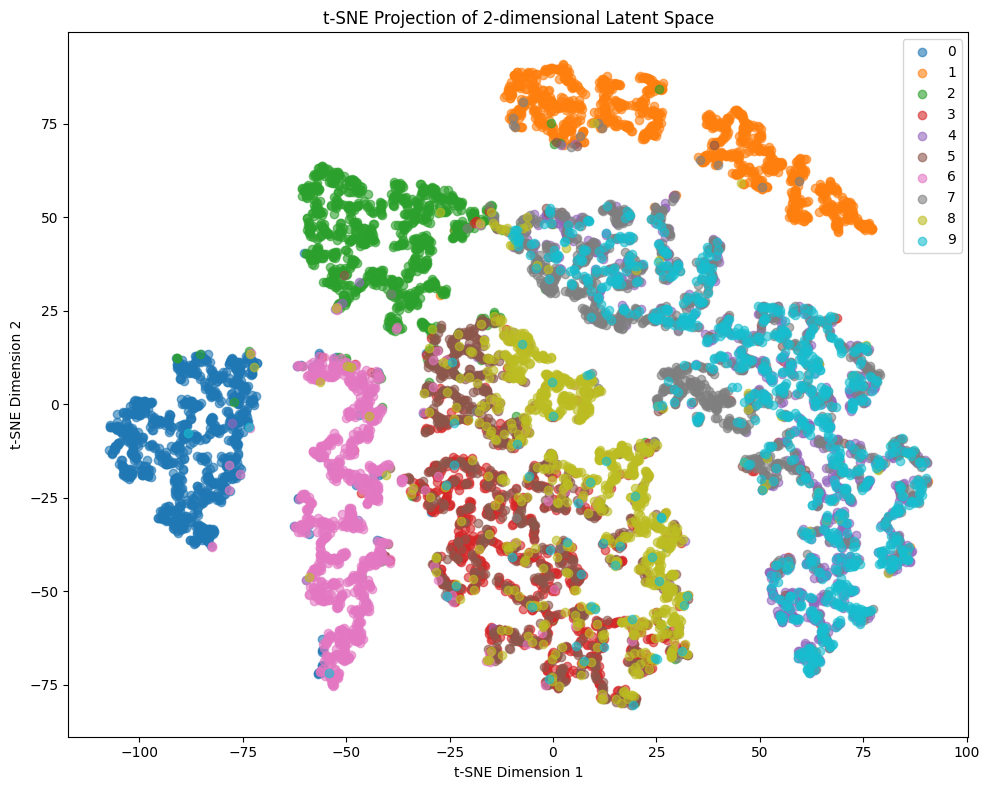

In [ ]:
# Collect embeddings for visualization
all_embeddings = []
all_labels = []
num_samples = 0

model.eval()
with torch.no_grad():
    for images, labels in train_loader:
        if num_samples >= 10000:
            break

        images = images.to(cuda_device)
        current_batch_size = min(images.size(0), 10000 - num_samples)

        # Extract embeddings
        embeddings = model.encoder(images[:current_batch_size]).cpu().numpy()
        batch_labels = labels[:current_batch_size].numpy()

        all_embeddings.append(embeddings)
        all_labels.append(batch_labels)

        num_samples += current_batch_size

# Stack all collected embeddings and labels
all_embeddings = np.vstack(all_embeddings)
all_labels = np.concatenate(all_labels)
embedding_size = all_embeddings.shape[1]
print(f"Collected {all_embeddings.shape[0]} embeddings with dimension {embedding_size}")

# Visualize with PCA
print("PCA visualization")
plot_latent_space_with_pca(
    all_embeddings,
    all_labels,
    title=f"PCA Projection of {embedding_size}-dimensional Latent Space"
)

# Visualize with t-SNE
print("t-SNE visualization")
plot_latent_space_with_tsne(
    all_embeddings,
    all_labels,
    title=f"t-SNE Projection of {embedding_size}-dimensional Latent Space"
)

##Modify dimension and generate GIF (Task 6,7)

---



In [ ]:
import imageio

#The first dimension of the latent vector
def create_interpolation_gif_dim1(model, image, device=cuda_device, save_path="dimension1.gif"):
    model.eval()
    images = []

    with torch.no_grad():
        image = image.to(device)
        embedding = model.encoder(image.unsqueeze(0)).squeeze(0).cpu().numpy()

        for val in np.arange(-10, 10.1, 0.1):
            modified = embedding.copy()
            modified[0] = val  # Change 1st dimension
            modified_tensor = torch.tensor(modified, dtype=torch.float32).unsqueeze(0).to(device)
            reconstructed = model.decoder(modified_tensor).cpu().squeeze().numpy()
            img = (reconstructed * 255).astype(np.uint8)
            images.append(img)

    imageio.mimsave(save_path, images, fps=15)
    print(f"GIF saved to {save_path}")

# Select one image from the test set
test_iter = iter(test_loader)
image, _ = next(test_iter)
image = image[0]

# Generate GIF
create_interpolation_gif_dim1(model, image)


GIF saved to dimension1.gif


In [ ]:
#The second dimension of the latent vector
def create_interpolation_gif_dim2(model, image, device=cuda_device, save_path="dimension2.gif"):
    model.eval()
    images = []

    with torch.no_grad():
        image = image.to(device)
        embedding = model.encoder(image.unsqueeze(0)).squeeze(0).cpu().numpy()

        for val in np.arange(-10, 10.1, 0.1):
            modified = embedding.copy()
            modified[1] = val  # Change 2nd dimension
            modified_tensor = torch.tensor(modified, dtype=torch.float32).unsqueeze(0).to(device)
            reconstructed = model.decoder(modified_tensor).cpu().squeeze().numpy()
            img = (reconstructed * 255).astype(np.uint8)
            images.append(img)

    imageio.mimsave(save_path, images, fps=15)
    print(f"GIF saved to {save_path}")

# Generate GIF using the same image
create_interpolation_gif_dim2(model, image)

GIF saved to dimension2.gif
